# Quick start

This notebook takes about five minutes. It computes the mean, variance, and Fano factor of
level crossings for a stochastic damped harmonic oscillator, then compares damping ratios.

- **Mean rate**: crossings per unit time (Kac–Rice formula). It depends only on $r(0)$ and $r''(0)$.
- **Variance** of the number of crossings in a window of length $T$.
- **Fano factor** $F = \mathrm{Var}[N]/\mathbb{E}[N]$: below 1 means crossings are more regular
  than a Poisson process, above 1 means they cluster.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from gaussian_crossings import GaussianCrossings
from gaussian_crossings.process import r_damped_harmonic_oscillator_noise

# Stochastic damped harmonic oscillator with temperature 1, natural frequency 1,
# and damping ratio 0.5. Its stationary variance is temp / omega0**2 = 1.
model = GaussianCrossings(r_damped_harmonic_oscillator_noise, temp=1.0, omega0=1.0, zeta=0.5)
model

GaussianUpCrossings(r_damped_harmonic_oscillator_noise, u=0, temp=1.0, omega0=1.0, zeta=0.5)

## Mean, variance, and Fano factor at one threshold

`fano_factor(u)` is the long-time limit. `fano_factor(u, T=...)` is the ratio for counts in
windows of length `T`, which is the number to compare with data cut into windows of that length.

In [2]:
u = 0.5  # threshold (the process has unit variance here)

print(f"mean upcrossings per unit time : {model.mean_rate(u):.4f}")
print(f"mean upcrossings in T = 120    : {model.mean(120.0, u):.3f}")
print(f"variance of the count, T = 120 : {model.variance(120.0, u):.3f}")
print(f"Fano factor, windows of T = 120: {model.fano_factor(u, T=120.0):.4f}")
print(f"long-time Fano factor          : {model.fano_factor(u):.4f}")

mean upcrossings per unit time : 0.1405
mean upcrossings in T = 120    : 16.854
variance of the count, T = 120 : 6.985
Fano factor, windows of T = 120: 0.4145
long-time Fano factor          : 0.4071


## Upcrossings, downcrossings, and all crossings

`kind` selects which crossings to count. Up- and downcrossings have identical statistics.
Because they alternate, the long-time Fano factor of all crossings is exactly twice the
upcrossing one.

In [3]:
for kind in ["up", "down", "total"]:
    print(f"{kind:>5}: mean rate {model.mean_rate(u, kind=kind):.4f}, "
          f"long-time Fano factor {model.fano_factor(u, kind=kind):.4f}")

   up: mean rate 0.1405, long-time Fano factor 0.4071
 down: mean rate 0.1405, long-time Fano factor 0.4071
total: mean rate 0.2809, long-time Fano factor 0.8143


## Whole curves in one call

Passing an array of thresholds returns an array. Here three damping ratios share the same
temperature and natural frequency, so their mean crossing rates are identical, yet their Fano
factors differ: the underdamped oscillator crosses regularly ($F<1$), while the overdamped one
produces clustered recrossings ($F>1$).

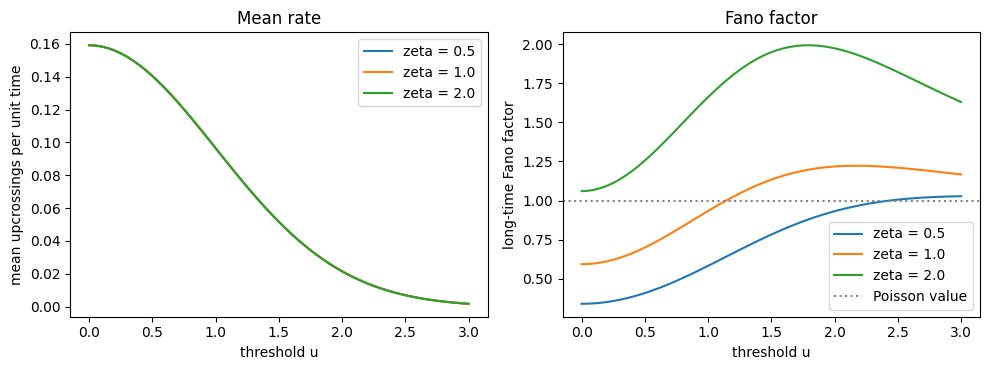

In [4]:
levels = np.linspace(0.0, 3.0, 61)
fig, (left, right) = plt.subplots(1, 2, figsize=(10, 3.8))
for zeta in [0.5, 1.0, 2.0]:
    m = GaussianCrossings(r_damped_harmonic_oscillator_noise, temp=1.0, omega0=1.0, zeta=zeta)
    left.plot(levels, m.mean_rate(levels), label=f"zeta = {zeta}")
    right.plot(levels, m.fano_factor(levels), label=f"zeta = {zeta}")
right.axhline(1.0, color="gray", linestyle=":", label="Poisson value")
left.set(xlabel="threshold u", ylabel="mean upcrossings per unit time", title="Mean rate")
right.set(xlabel="threshold u", ylabel="long-time Fano factor", title="Fano factor")
left.legend()
right.legend()
fig.tight_layout()

## Finite windows versus the long-time limit

For windows only a few correlation times long, the windowed Fano factor can differ from the
long-time value. When comparing with data, use the window length of the data.

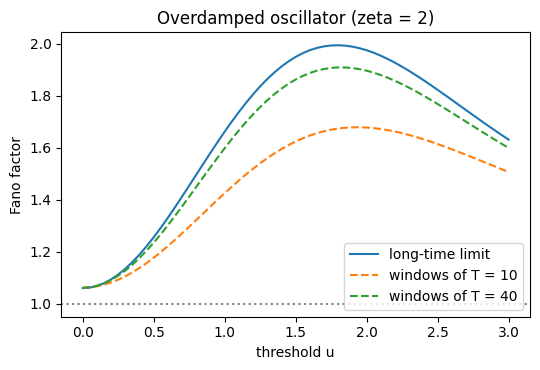

In [5]:
overdamped = GaussianCrossings(r_damped_harmonic_oscillator_noise, temp=1.0, omega0=1.0, zeta=2.0)
fig, ax = plt.subplots(figsize=(5.5, 3.8))
ax.plot(levels, overdamped.fano_factor(levels), label="long-time limit")
for T in [10.0, 40.0]:
    ax.plot(levels, overdamped.fano_factor(levels, T=T), linestyle="--", label=f"windows of T = {T:g}")
ax.axhline(1.0, color="gray", linestyle=":")
ax.set(xlabel="threshold u", ylabel="Fano factor", title="Overdamped oscillator (zeta = 2)")
ax.legend()
fig.tight_layout()

## Next steps

- [02 — your own covariance](02_custom_covariance.ipynb)
- [03 — from data to a Fano factor](03_fano_from_data.ipynb)
- [04 — telling models apart](04_model_discrimination.ipynb)